In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/fer2013.csv")

print(df.shape)
print(df.columns)
print(df.head())

(35887, 3)
Index(['emotion', 'pixels', 'Usage'], dtype='str')
   emotion                                             pixels     Usage
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...  Training
1        0  151 150 147 155 148 133 111 140 170 174 182 15...  Training
2        2  231 212 156 164 174 138 161 173 182 200 106 38...  Training
3        4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...  Training
4        6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...  Training


In [3]:
print(df["emotion"].value_counts())

emotion
3    8989
6    6198
4    6077
2    5121
0    4953
5    4002
1     547
Name: count, dtype: int64


shape قبل از reshape: (2304,)
shape بعد از reshape: (48, 48)


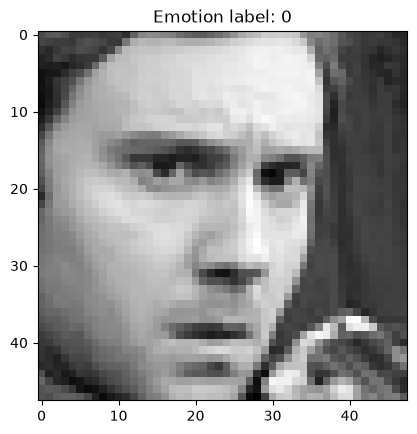

In [4]:
sample = df.iloc[0]
pixels = np.array(sample["pixels"].split(), dtype="int")
print("shape قبل از reshape:", pixels.shape)

image = pixels.reshape(48, 48)
print("shape بعد از reshape:", image.shape)

plt.imshow(image, cmap="gray")
plt.title(f"Emotion label: {sample['emotion']}")
plt.show()


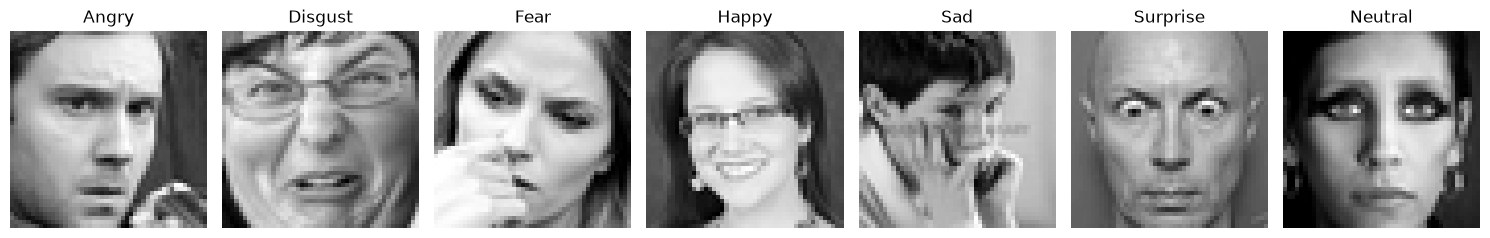

In [5]:
emotion_labels = {
    0: "Angry",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Sad",
    5: "Surprise",
    6: "Neutral"
}

fig, axes = plt.subplots(1, 7, figsize=(15, 3))

for emotion_num, emotion_name in emotion_labels.items():
    sample_row = df[df["emotion"] == emotion_num].iloc[0]
    pixels = np.array(sample_row["pixels"].split(), dtype="int")
    image = pixels.reshape(48, 48)
    axes[emotion_num].imshow(image, cmap="gray")
    axes[emotion_num].set_title(emotion_name)
    axes[emotion_num].axis("off")

plt.tight_layout()
plt.show()


In [6]:
print(df["Usage"].value_counts())

Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64


In [ ]:
def preprocess_row(pixel_str):
    pixels = np.array(pixel_str.split(), dtype="float32")
    image = pixels.reshape(48,48,1)
    image = image / 255.0
    return image



X_all = np.stack(df["pixels"].apply(preprocess_row))
Y_all = df["emotion"].values


print("X_all shape", X_all.shape)
print("Y_all shape", Y_all.shape)




X_all shape (35887, 48, 48, 1)
Y_all shape [0 0 2 ... 0 3 2]


In [11]:
train_df = df[df["Usage"]== "Training"]
val_df = df[df["Usage"] == "PublicTest"]
test_df = df[df["Usage"] == "PrivateTest"]

print ("train df", train_df.shape)
print ("val df", val_df.shape)
print ("test df", test_df.shape)

train df (28709, 3)
val df (3589, 3)
test df (3589, 3)


In [13]:
x_train = np.stack(train_df["pixels"].apply(preprocess_row))
y_train = train_df["emotion"].values

x_val = np.stack(val_df["pixels"].apply(preprocess_row))
y_val = val_df["emotion"].values


x_test = np.stack(test_df["pixels"].apply(preprocess_row))
y_test = test_df["emotion"].values

print("x train shape:" ,x_train.shape,"y train shape:" , y_train.shape )
print("x validation shape:" ,x_val.shape,"y validation shape:" , y_val.shape )
print("x test shape:" ,x_test.shape,"y test shape:" , y_test.shape )




x train shape: (28709, 48, 48, 1) y train shape: (28709,)
x validation shape: (3589, 48, 48, 1) y validation shape: (3589,)
x test shape: (3589, 48, 48, 1) y test shape: (3589,)
